# 4. Wczytywanie danych z API

**API** (*Application Programming Interface*) to interfejs do komunikacji między aplikacjami.

**Dlaczego API?**
- Dostęp do danych w czasie rzeczywistym
- Dane zawsze aktualne (nie trzeba pobierać plików)
- Większość serwisów webowych udostępnia API (GitHub, Twitter, Google, etc.)

**Wymagania:**
```bash
pip install requests
```

In [1]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

%matplotlib inline

## Przykład: GitHub API - najpopularniejsze repozytoria Pythona

Użyjemy GitHub API do pobrania najpopularniejszych repozytoriów napisanych w Pythonie.

In [18]:
# URL do GitHub API - wyszukiwanie repozytoriów
endpoint = "https://api.github.com/search/repositories"  # url

# Parametry zapytania
data = {
    "q": "language:python",
    "sort": "stars",
    "order": "desc",
    "per_page": 20
}

# Wykonaj zapytanie GET
response = requests.get(endpoint, params=data)

# Sprawdź status
print(f"Status: {response.status_code}")
print(f"URL: {response.url}")

# Pobierz dane
data = response.json()

print(f"\nZnaleziono: {data['total_count']:,} repozytoriów")
print(f"Pobrano: {len(data['items'])} repozytoriów")

Status: 200
URL: https://api.github.com/search/repositories?q=language%3Apython&sort=stars&order=desc&per_page=20

Znaleziono: 30,249,065 repozytoriów
Pobrano: 20 repozytoriów


In [20]:
requests.__version__

'2.34.2'

In [23]:
# Bezpośrednio z listy słowników do DataFrame
df = pd.DataFrame(data['items'])

# Wybierz tylko potrzebne kolumny
df = df[  ['name', 'stargazers_count', 'forks_count', 'description', 'html_url']  ]

# # Zmień nazwy kolumn na polskie (opcjonalnie)
df.columns = ['nazwa', 'gwiazdki', 'forki', 'opis', 'url']

# print("Top 10 najpopularniejszych repozytoriów Pythona:")
df.head(10)

,nazwa,gwiazdki,forki,opis,url
0,public-apis,444896,48812,A collective list of free APIs,https://github.com/public-apis/public-apis
1,free-programming-books,390950,66462,:books: Freely available programming books,https://github.com/EbookFoundation/free-progra...
2,system-design-primer,355371,56965,Learn how to design large-scale systems. Prep ...,https://github.com/donnemartin/system-design-p...
3,awesome-python,305416,28181,"An opinionated list of Python frameworks, libr...",https://github.com/vinta/awesome-python
4,Python,222290,50797,All Algorithms implemented in Python,https://github.com/TheAlgorithms/Python
5,hermes-agent,205424,37071,The agent that grows with you,https://github.com/NousResearch/hermes-agent
6,AutoGPT,185203,46122,AutoGPT is the vision of accessible AI for eve...,https://github.com/Significant-Gravitas/AutoGPT
7,yt-dlp,174140,14683,A feature-rich command-line audio/video downlo...,https://github.com/yt-dlp/yt-dlp
8,stable-diffusion-webui,163937,30373,Stable Diffusion web UI,https://github.com/AUTOMATIC1111/stable-diffus...
9,HelloGitHub,163165,12251,:octocat: 分享 GitHub 上有趣、入门级的开源项目。Share interes...,https://github.com/521xueweihan/HelloGitHub


## Podstawowa analiza

In [24]:
print("Statystyki:")
print(df[['gwiazdki', 'forki']].describe())

print(f"\nNajpopularniejsze: {df.iloc[0]['nazwa']} ({df.iloc[0]['gwiazdki']:,} ⭐)")
print(f"Średnia liczba gwiazdek: {df['gwiazdki'].mean():,.0f}")
print(f"Średnia liczba forków: {df['forki'].mean():,.0f}")

Statystyki:
            gwiazdki         forki
count      20.000000     20.000000
mean   200380.450000  28083.800000
std     95986.409648  17547.481483
min    116024.000000   9358.000000
25%    140578.750000  13481.000000
50%    162587.500000  22546.500000
75%    209640.500000  39333.750000
max    444896.000000  66462.000000

Najpopularniejsze: public-apis (444,896 ⭐)
Średnia liczba gwiazdek: 200,380
Średnia liczba forków: 28,084


## Wizualizacja

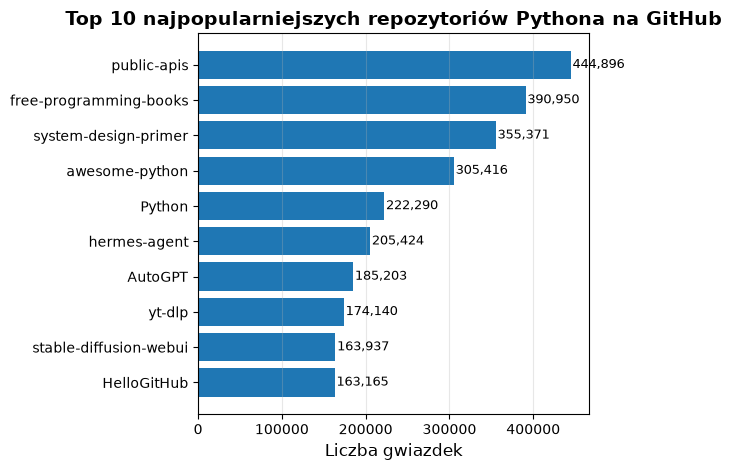

In [39]:
# Top 10 według gwiazdek
top10 = df.head(10)

fig, ax = plt.subplots()

# # Wykres słupkowy poziomy
X = top10['nazwa']
Y = top10['gwiazdki']

ax.barh(X, Y)

# Etykiety
ax.set_yticks(range(len(top10)))
ax.set_yticklabels(top10['nazwa'])

ax.set_xlabel('Liczba gwiazdek', fontsize=12)
ax.set_title('Top 10 najpopularniejszych repozytoriów Pythona na GitHub', 
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Dodaj wartości na słupkach
for i, v in enumerate(top10['gwiazdki']):
    ax.text(v + 2000, i, f'{v:,}', va='center', fontsize=9)

# # Odwróć oś Y (najlepszy na górze)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

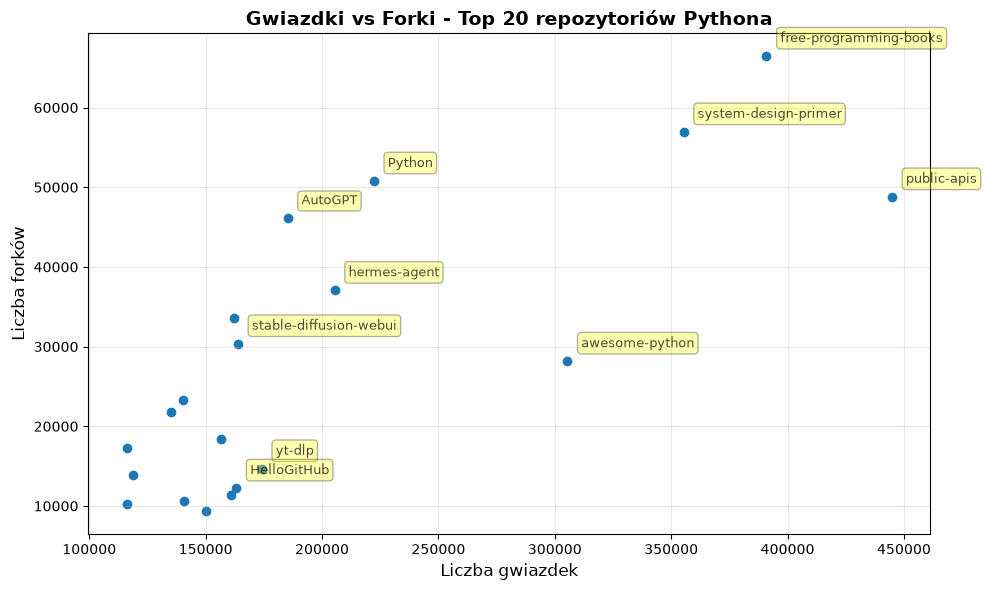

In [42]:
# Gwiazdki vs Forki
fig, ax = plt.subplots(figsize=(10, 6))

X = df['gwiazdki']
Y = df['forki']

ax.scatter(X, Y)

ax.set_xlabel('Liczba gwiazdek', fontsize=12)
ax.set_ylabel('Liczba forków', fontsize=12)
ax.set_title('Gwiazdki vs Forki - Top 20 repozytoriów Pythona', 
             fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Dodaj etykiety dla top 10
for i in range(10):
    ax.annotate(df.iloc[i]['nazwa'], 
                xy=(df.iloc[i]['gwiazdki'], df.iloc[i]['forki']),
                xytext=(10, 10), textcoords='offset points',
                fontsize=9, alpha=0.7,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.3))

plt.tight_layout()
plt.show()

## Podsumowanie

**Co zrobiliśmy:**
1. ✅ Zapytanie GET do GitHub API
2. ✅ Pobranie top 20 repozytoriów Pythona
3. ✅ Konwersja JSON → DataFrame
4. ✅ Wizualizacja: wykres słupkowy i scatter

**Podstawowe komendy:**
```python
response = requests.get(url, params=params, timeout=10)
data = response.json()  # JSON → dict/list
df = pd.DataFrame(data)  # dict/list → DataFrame
```

**HTTP Status Codes:**
- **200** - OK (sukces)
- **400** - Bad Request (błędne parametry)
- **401** - Unauthorized (brak autoryzacji)
- **403** - Forbidden (limit zapytań przekroczony)
- **404** - Not Found (nie znaleziono)
- **500** - Internal Server Error (błąd serwera)

**Inne publiczne API (bez klucza):**
- JSONPlaceholder: `https://jsonplaceholder.typicode.com/users`
- REST Countries: `https://restcountries.com/v3.1/all`
- CoinGecko: `https://api.coingecko.com/api/v3/coins/markets?vs_currency=usd`